In [34]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn.feature_selection import mutual_info_classif

from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.metrics import classification_report

import pickle

# To remove scientific notations
pd.options.display.float_format = '{:.6f}'.format

# to run multiple things in a single cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# to hide warning meassages
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\91630\Downloads\alzheimers_disease_data.csv")
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [3]:
df.shape
df.info()

(2149, 35)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [4]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


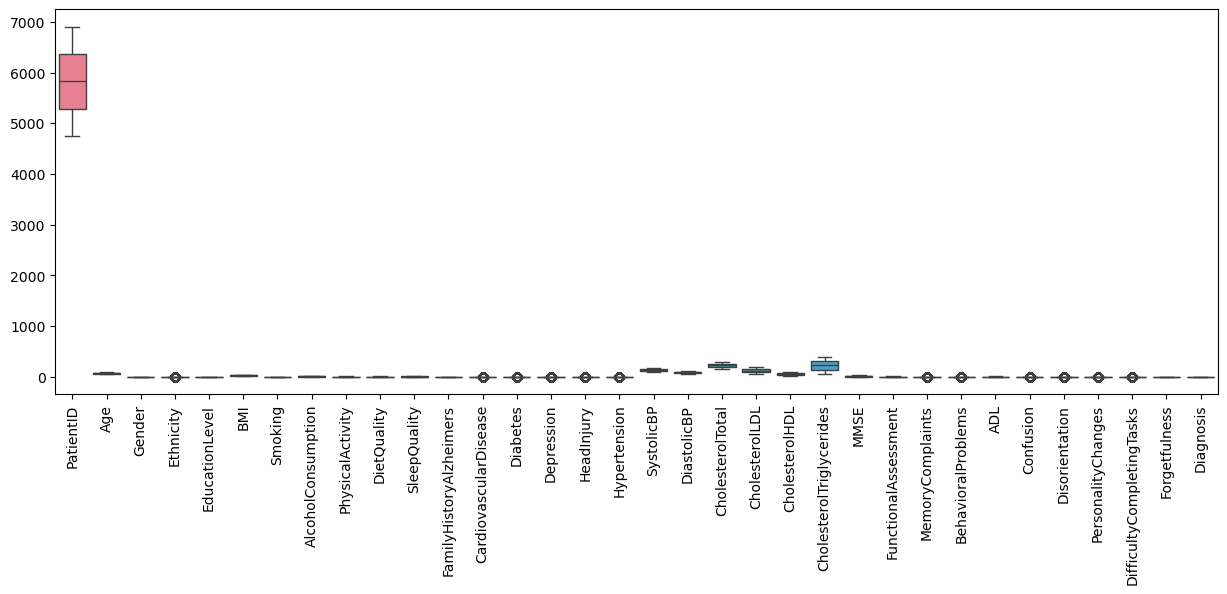

In [5]:
plt.figure(figsize=(15,5))
sns.boxplot(df)
plt.xticks(rotation=90);

In [6]:
df[df.duplicated()]

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge


### EDA

##### Dropping nonusefull columns

In [7]:
df.drop(columns=['PatientID','DoctorInCharge'],inplace=True)

In [8]:
df.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


### categorical:
+ Gender
+ Ethnicity
+ EducationLevel
+ Smoking
+ FamilyHistoryAlzheimers
+ CardivascularDisease
+ Diabetes
+ Depression
+ HeadInjury
+ Hypertension
+ MemoryComplaints
+ BehavioralProblems
+ Confusion
+ Disorientation
+ PersonalityChanges
+ DifficultyCompletingTasks
+ Forgetfulness
+ Diagnosis

### Numerical

+ Age
+ BMI
+ AlcoholConsumption
+ PhysicalActivity
+ DietQuality
+ SleepQuality
+ SystolicBP
+ DiastolicBP
+ CholesterolTotal
+ CholesterolLDL
+ CholesterolHDL
+ CholesterolTriglycerides
+ MMSE
+ FunctionalAssessment
+ ADL

In [59]:
# Identify numerical columns: columns with more than 10 unique values are considered numerical
numerical_columns = [col for col in df.columns if df[col].nunique() > 10]
numerical_columns

['Age',
 'BMI',
 'AlcoholConsumption',
 'PhysicalActivity',
 'DietQuality',
 'SleepQuality',
 'SystolicBP',
 'DiastolicBP',
 'CholesterolTotal',
 'CholesterolLDL',
 'CholesterolHDL',
 'CholesterolTriglycerides',
 'MMSE',
 'FunctionalAssessment',
 'ADL']

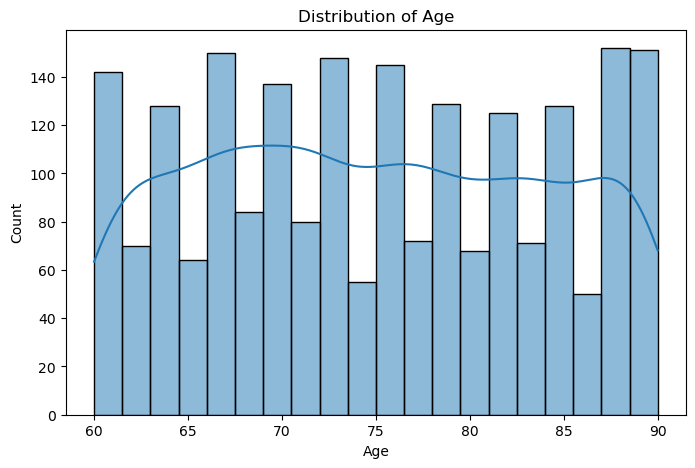

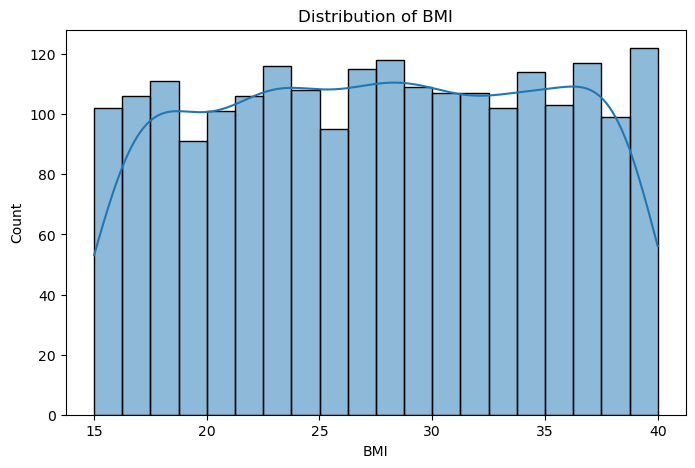

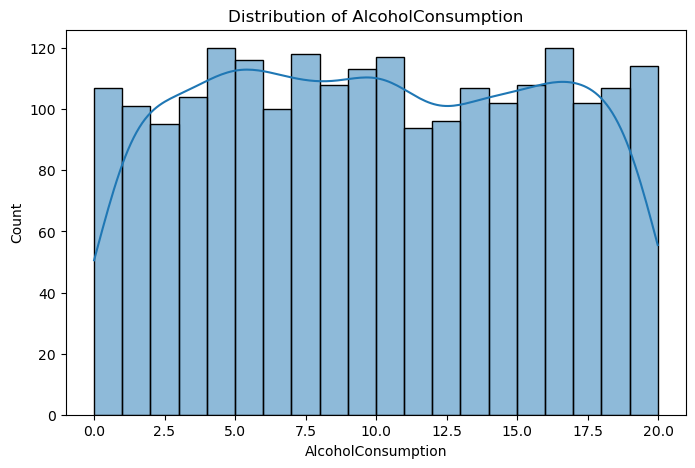

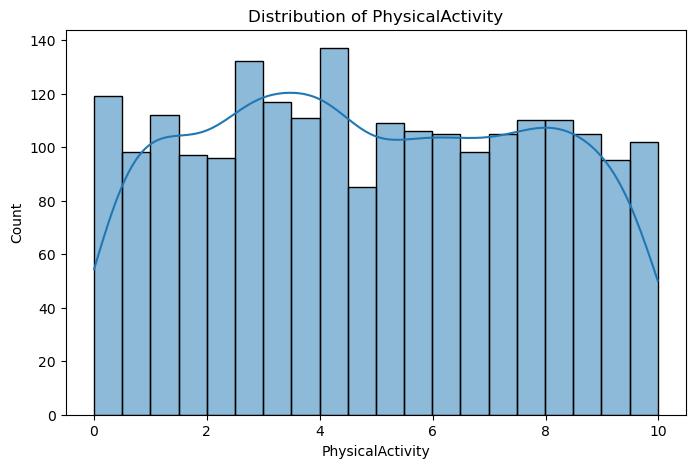

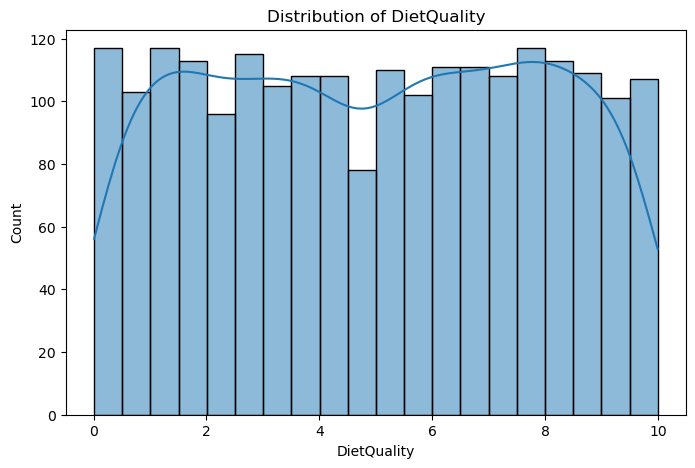

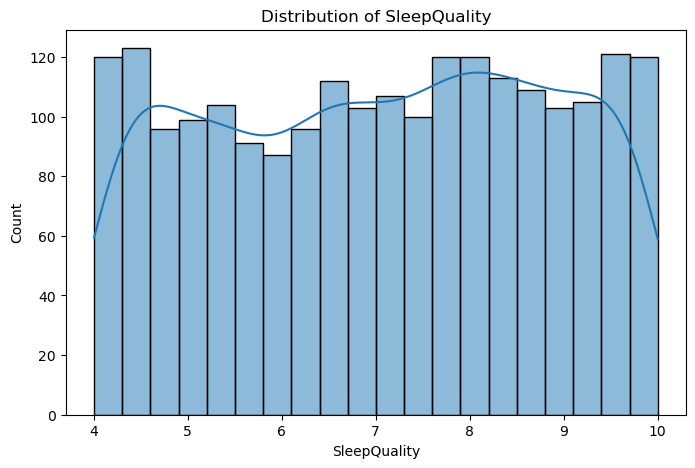

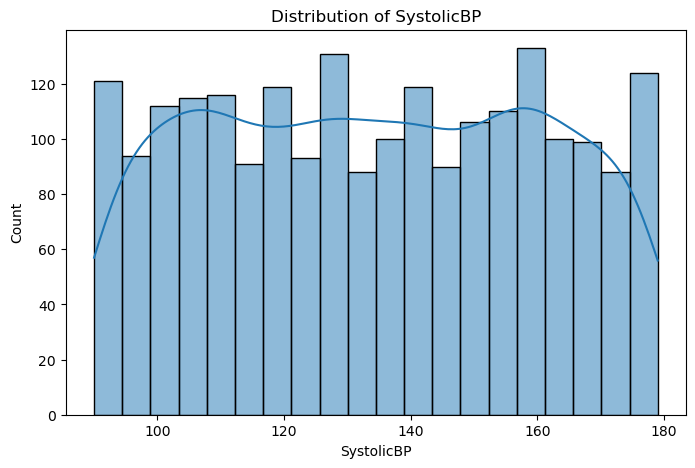

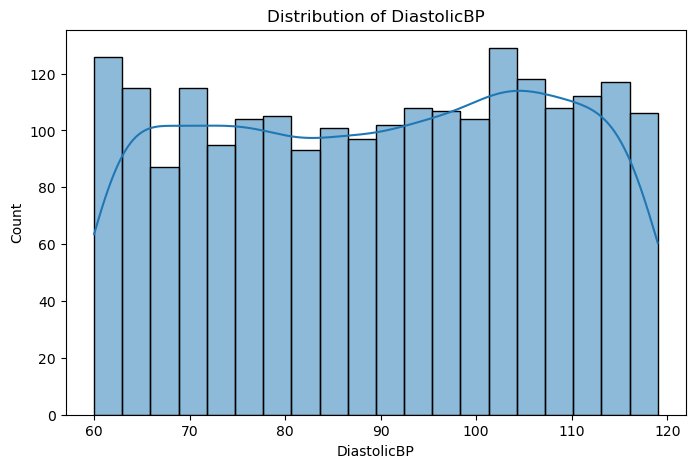

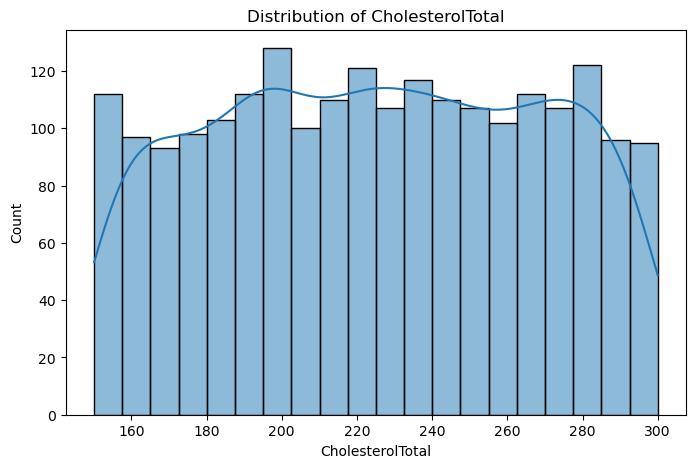

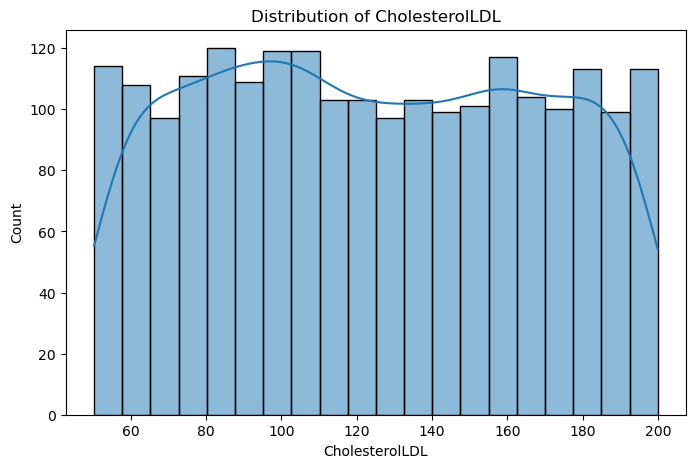

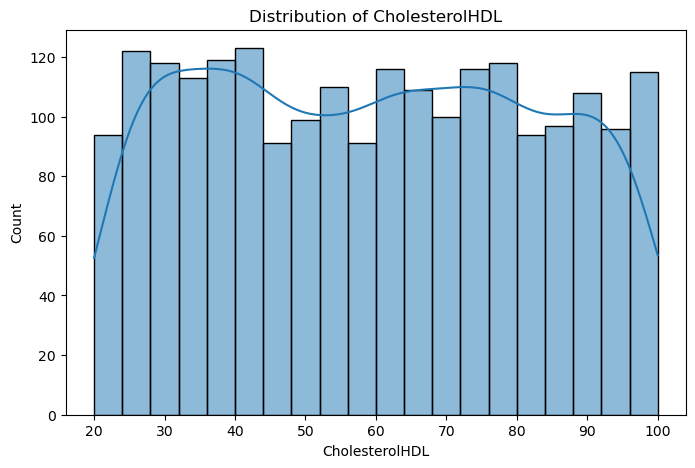

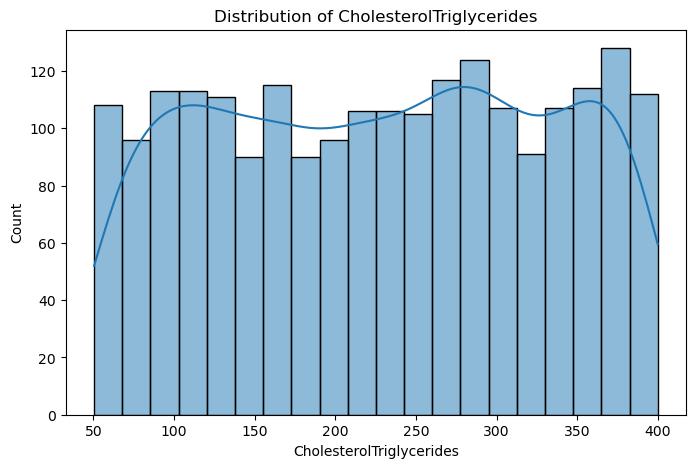

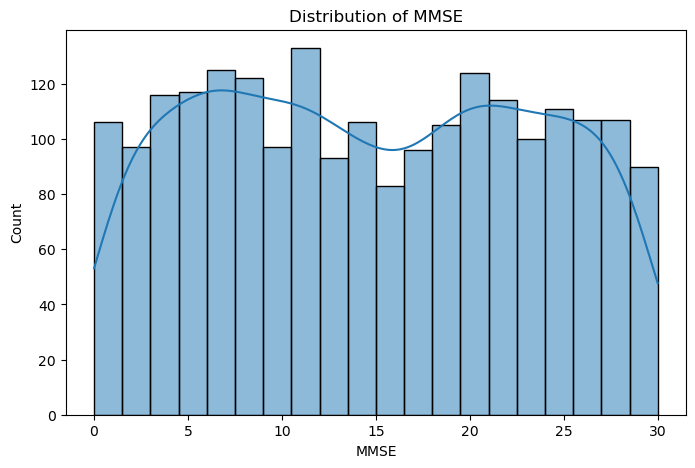

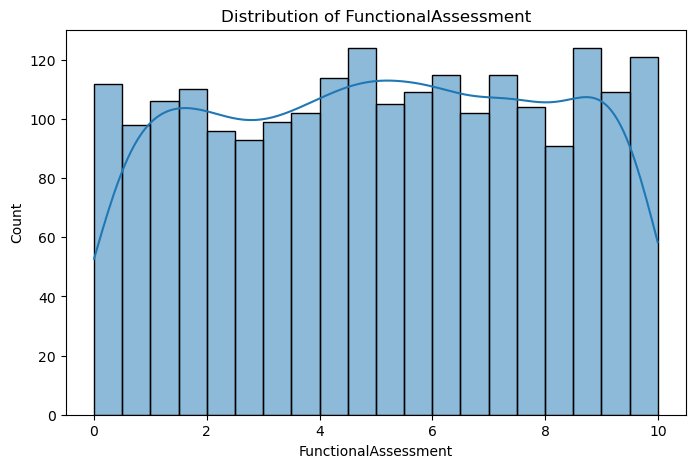

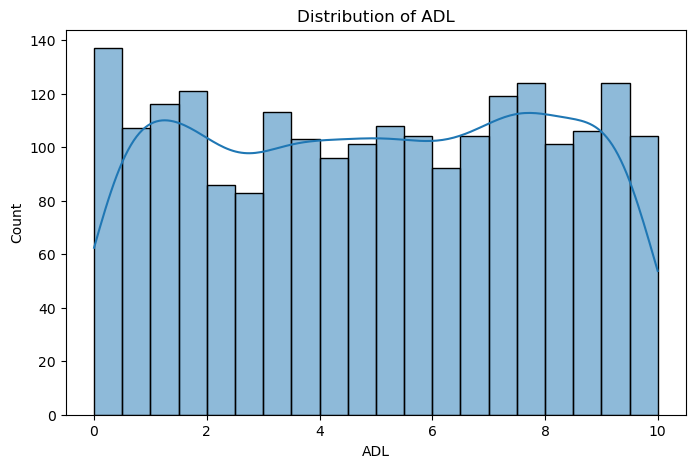

In [113]:
# Plot histogram for each numerical column
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, kde=True, bins=20)
    plt.title(f'Distribution of {column}')
plt.show();

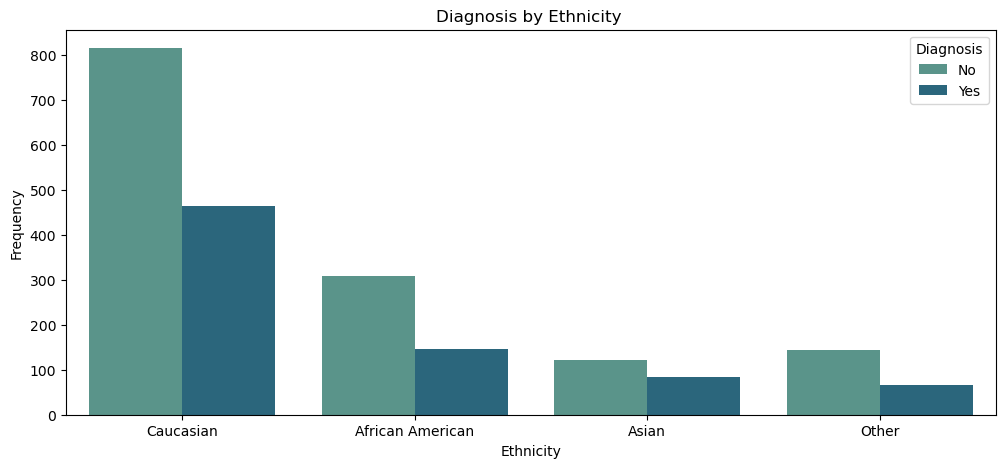

In [114]:
plt.figure(figsize=(12,5))
sns.countplot(x='Ethnicity', data=df, hue='Diagnosis', palette='crest')
plt.title('Diagnosis by Ethnicity ')
plt.xlabel('Ethnicity')
plt.ylabel('Frequency')
plt.xticks(ticks= [0,1,2,3], labels=['Caucasian','African American','Asian','Other'])
plt.legend(title='Diagnosis', loc='upper right', labels=['No', 'Yes']);

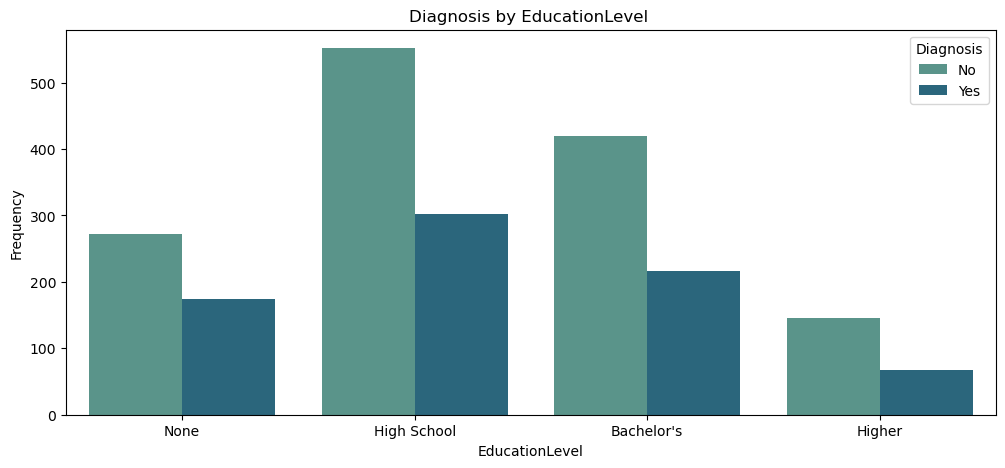

In [115]:
plt.figure(figsize=(12,5))
sns.countplot(x='EducationLevel', data=df, hue='Diagnosis', palette='crest')
plt.title('Diagnosis by EducationLevel ')
plt.xlabel('EducationLevel')
plt.ylabel('Frequency')
plt.xticks(ticks= [0,1,2,3], labels=['None', 'High School', 'Bachelor\'s', 'Higher'])
plt.legend(title='Diagnosis', loc='upper right', labels=['No', 'Yes']);

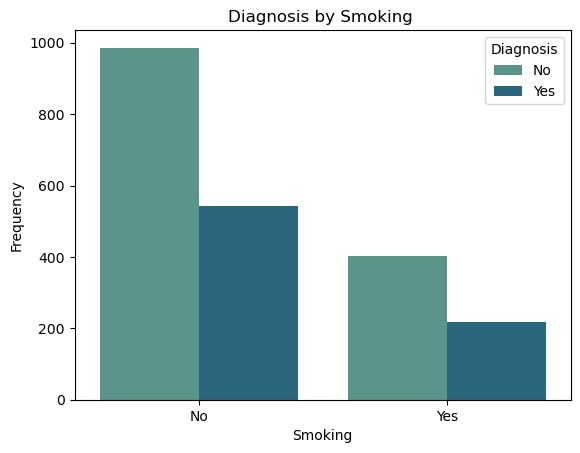

In [116]:
sns.countplot(x='Smoking', data=df, hue='Diagnosis', palette='crest')
plt.title('Diagnosis by Smoking ')
plt.xlabel('Smoking')
plt.ylabel('Frequency')
plt.xticks(ticks= [0,1], labels=['No','Yes'])
plt.legend(title='Diagnosis', loc='upper right', labels=['No', 'Yes']);

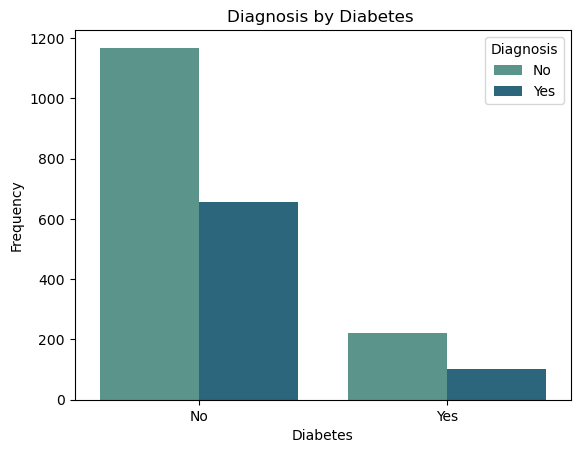

In [117]:
sns.countplot(x='Diabetes', data=df, hue='Diagnosis', palette='crest')
plt.title('Diagnosis by Diabetes ')
plt.xlabel('Diabetes')
plt.ylabel('Frequency')
plt.xticks(ticks= [0,1], labels=['No','Yes'])
plt.legend(title='Diagnosis', loc='upper right', labels=['No', 'Yes']);

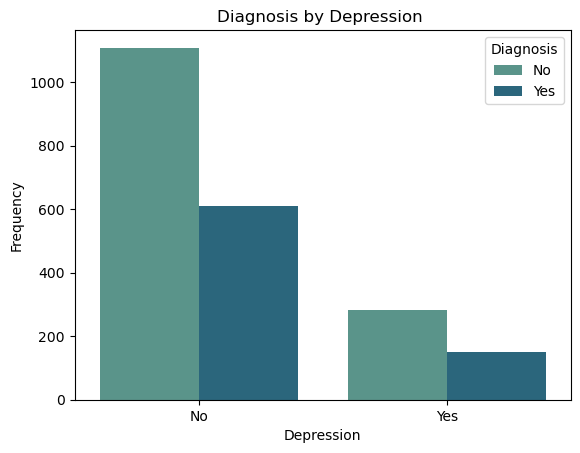

In [118]:
sns.countplot(x='Depression', data=df, hue='Diagnosis', palette='crest')
plt.title('Diagnosis by Depression ')
plt.xlabel('Depression')
plt.ylabel('Frequency')
plt.xticks(ticks= [0,1], labels=['No','Yes'])
plt.legend(title='Diagnosis', loc='upper right', labels=['No', 'Yes']);

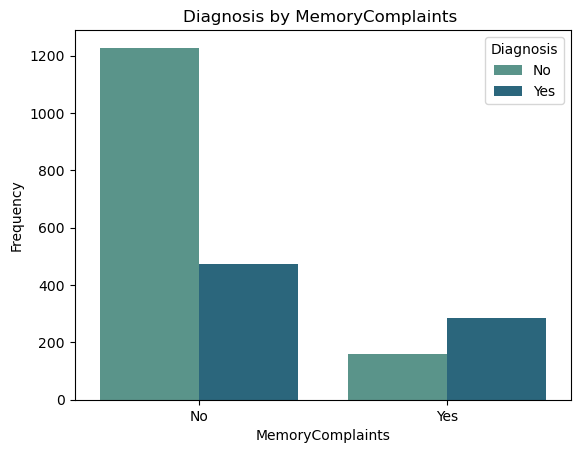

In [119]:
sns.countplot(x='MemoryComplaints', data=df, hue='Diagnosis', palette='crest')
plt.title('Diagnosis by MemoryComplaints ')
plt.xlabel('MemoryComplaints')
plt.ylabel('Frequency')
plt.xticks(ticks= [0,1], labels=['No','Yes'])
plt.legend(title='Diagnosis', loc='upper right', labels=['No', 'Yes']);

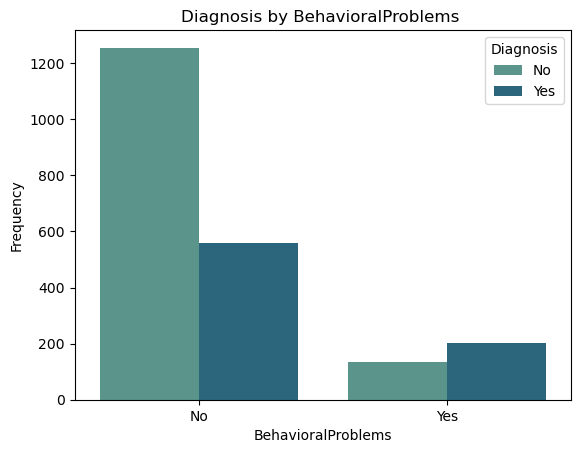

In [120]:
sns.countplot(x='BehavioralProblems', data=df, hue='Diagnosis', palette='crest')
plt.title('Diagnosis by BehavioralProblems ')
plt.xlabel('BehavioralProblems')
plt.ylabel('Frequency')
plt.xticks(ticks= [0,1], labels=['No','Yes'])
plt.legend(title='Diagnosis', loc='upper right', labels=['No', 'Yes']);

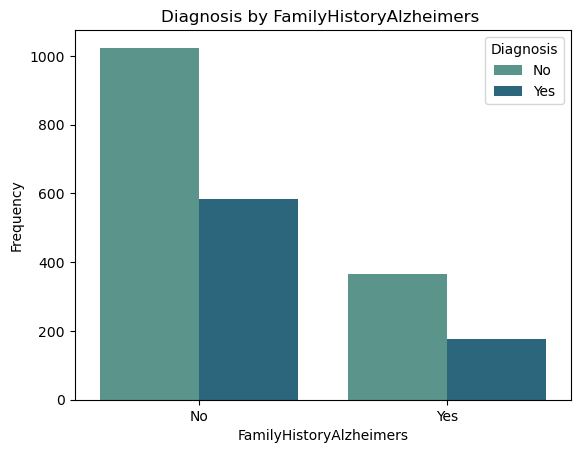

In [121]:
sns.countplot(x='FamilyHistoryAlzheimers', data=df, hue='Diagnosis', palette='crest')
plt.title('Diagnosis by FamilyHistoryAlzheimers ')
plt.xlabel('FamilyHistoryAlzheimers')
plt.ylabel('Frequency')
plt.xticks(ticks= [0,1], labels=['No','Yes'])
plt.legend(title='Diagnosis', loc='upper right', labels=['No', 'Yes']);

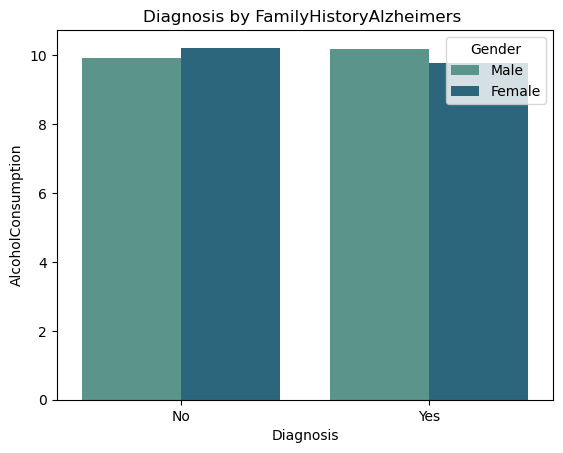

In [122]:
ax = sns.barplot(data=df,x='Diagnosis',y='AlcoholConsumption',hue='Gender',ci=False, palette='crest')
plt.title('Diagnosis by FamilyHistoryAlzheimers ')
plt.xticks(ticks= [0,1], labels=['No','Yes'])
handles, previous_labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,title= 'Gender', loc= 'upper right', labels=['Male','Female']);

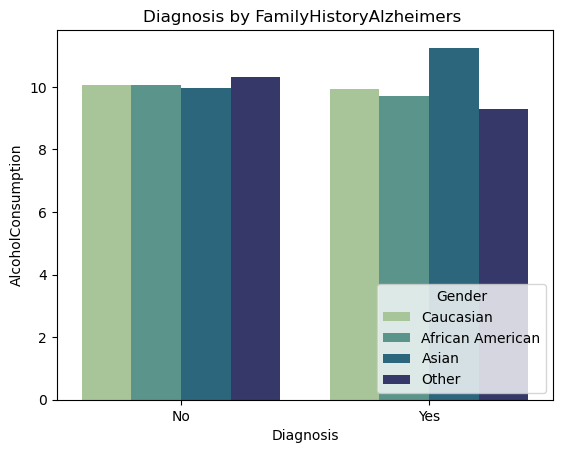

In [123]:
ax = sns.barplot(data=df,x='Diagnosis',y='AlcoholConsumption',hue='Ethnicity', ci=False, palette='crest')
plt.title('Diagnosis by FamilyHistoryAlzheimers ')
plt.xticks(ticks= [0,1], labels=['No','Yes'])
handles, previous_labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,title= 'Gender', loc= 'lower right', labels=['Caucasian','African American','Asian','Other']);

### Data splitting

In [13]:
y = df['Diagnosis']
X = df.drop(columns=['Diagnosis'])

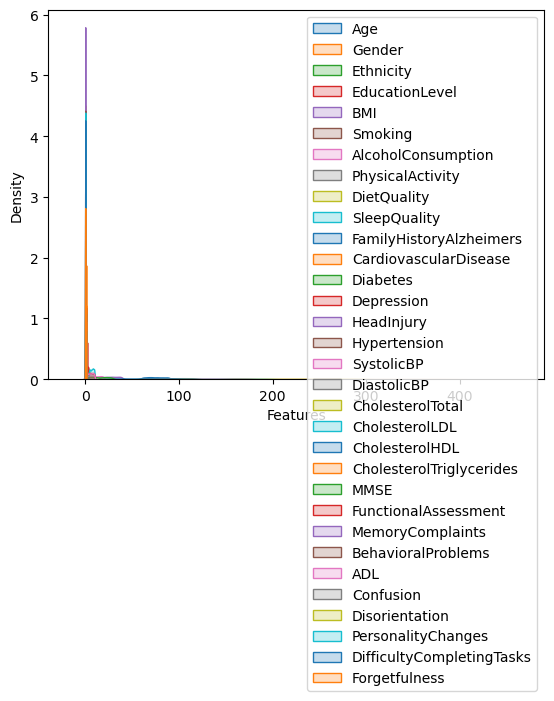

In [14]:
for i in range(len(X.columns)):
    sns.kdeplot(df ,x = X.columns[i],fill = True)
plt.xlabel('Features')
plt.legend(labels = X.columns)
plt.show();

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)
X_train.shape
X_test.shape
y_train.shape
y_test.shape

(1611, 32)

(538, 32)

(1611,)

(538,)

In [16]:
# Reindex
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [17]:
X_train.head()
X_test.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,65,0,1,1,15.828333,0,6.172108,8.009776,2.371043,9.330619,...,23.187809,7.769651,0,0,7.907006,0,0,0,0,1
1,60,0,1,3,28.597737,0,7.360575,8.465618,5.853249,4.458891,...,29.389350,9.853326,1,0,0.340165,0,1,0,0,1
2,80,1,0,1,29.093674,0,10.327453,2.424280,9.723906,9.572991,...,3.119302,0.092317,1,1,4.862053,0,0,0,0,0
3,65,1,0,0,35.141843,1,17.111404,6.645284,1.112379,7.568751,...,23.789999,6.197277,0,0,7.519209,0,0,0,0,1
4,60,0,0,2,29.402614,0,2.206331,1.191201,6.018892,9.842370,...,29.793070,5.039519,0,0,0.357248,1,1,0,0,1


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,88,1,1,0,26.341457,0,17.793866,1.016087,5.708032,9.325018,...,14.488641,7.307851,0,0,6.800703,1,0,0,0,1
1,76,0,1,2,30.998034,1,4.848165,0.377785,3.367394,7.872985,...,14.200631,3.170980,0,0,7.388050,0,0,0,0,1
2,73,0,0,1,19.060665,0,19.577591,9.290182,6.155534,8.472929,...,10.811239,9.013686,1,0,6.166283,0,0,0,1,1
3,77,1,0,3,36.391951,1,0.498616,7.621075,8.649806,8.639434,...,12.943559,7.826850,0,0,3.161108,1,0,0,0,0
4,71,0,1,0,39.291923,1,18.152064,0.084994,0.888331,7.799254,...,29.323470,8.746284,0,0,6.050739,0,0,0,0,0


In [18]:
y_train.head()
y_test.head()

0    0
1    0
2    1
3    0
4    0
Name: Diagnosis, dtype: int64

0    0
1    0
2    0
3    0
4    0
Name: Diagnosis, dtype: int64

In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1611 entries, 0 to 1610
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1611 non-null   int64  
 1   Gender                     1611 non-null   int64  
 2   Ethnicity                  1611 non-null   int64  
 3   EducationLevel             1611 non-null   int64  
 4   BMI                        1611 non-null   float64
 5   Smoking                    1611 non-null   int64  
 6   AlcoholConsumption         1611 non-null   float64
 7   PhysicalActivity           1611 non-null   float64
 8   DietQuality                1611 non-null   float64
 9   SleepQuality               1611 non-null   float64
 10  FamilyHistoryAlzheimers    1611 non-null   int64  
 11  CardiovascularDisease      1611 non-null   int64  
 12  Diabetes                   1611 non-null   int64  
 13  Depression                 1611 non-null   int64

In [20]:
for i in df.select_dtypes(include='int').columns:
    df[i].value_counts()

Age
88    84
68    84
72    82
76    81
71    80
90    79
67    77
60    74
70    74
66    73
89    72
77    72
78    72
84    71
83    71
62    70
63    69
80    68
61    68
87    68
82    68
73    66
65    64
75    64
69    63
64    59
79    57
85    57
81    57
74    55
86    50
Name: count, dtype: int64

Gender
1    1088
0    1061
Name: count, dtype: int64

Ethnicity
0    1278
1     454
3     211
2     206
Name: count, dtype: int64

EducationLevel
1    854
2    636
0    446
3    213
Name: count, dtype: int64

Smoking
0    1529
1     620
Name: count, dtype: int64

...

Disorientation
0    1809
1     340
Name: count, dtype: int64

PersonalityChanges
0    1825
1     324
Name: count, dtype: int64

DifficultyCompletingTasks
0    1808
1     341
Name: count, dtype: int64

Forgetfulness
0    1501
1     648
Name: count, dtype: int64

Diagnosis
0    1389
1     760
Name: count, dtype: int64

In [21]:
transformer = ColumnTransformer(transformers=[('t1',RobustScaler(),make_column_selector(dtype_include=['float'])),('t2',OrdinalEncoder(),[0,2,3,16,17])],remainder='passthrough')
X_train_trans = pd.DataFrame(transformer.fit_transform(X_train),columns = transformer.feature_names_in_)
X_test_trans = pd.DataFrame(transformer.transform(X_test),columns = transformer.feature_names_in_)

In [22]:
mutual_info = mutual_info_classif(X_train_trans,y_train,random_state=25)
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train_trans.columns
mutual_info.sort_values(ascending = False)

FamilyHistoryAlzheimers     0.103932
SleepQuality                0.091179
CardiovascularDisease       0.080911
BehavioralProblems          0.053535
DiastolicBP                 0.024063
Gender                      0.018900
CholesterolTriglycerides    0.017348
MemoryComplaints            0.011632
ADL                         0.009973
Ethnicity                   0.009345
Forgetfulness               0.008975
BMI                         0.006435
Age                         0.004119
CholesterolHDL              0.003709
PhysicalActivity            0.003381
Disorientation              0.001709
EducationLevel              0.001595
FunctionalAssessment        0.000998
AlcoholConsumption          0.000267
Depression                  0.000000
DifficultyCompletingTasks   0.000000
PersonalityChanges          0.000000
Confusion                   0.000000
Smoking                     0.000000
MMSE                        0.000000
HeadInjury                  0.000000
CholesterolLDL              0.000000
C

In [23]:
top_cols = list(mutual_info.sort_values(ascending = False).index[:19])
top_cols
X_train_features = X_train[top_cols]
X_test_features = X_test[top_cols]

['FamilyHistoryAlzheimers',
 'SleepQuality',
 'CardiovascularDisease',
 'BehavioralProblems',
 'DiastolicBP',
 'Gender',
 'CholesterolTriglycerides',
 'MemoryComplaints',
 'ADL',
 'Ethnicity',
 'Forgetfulness',
 'BMI',
 'Age',
 'CholesterolHDL',
 'PhysicalActivity',
 'Disorientation',
 'EducationLevel',
 'FunctionalAssessment',
 'AlcoholConsumption']

In [24]:
X_train_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1611 entries, 0 to 1610
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FamilyHistoryAlzheimers   1611 non-null   int64  
 1   SleepQuality              1611 non-null   float64
 2   CardiovascularDisease     1611 non-null   int64  
 3   BehavioralProblems        1611 non-null   int64  
 4   DiastolicBP               1611 non-null   int64  
 5   Gender                    1611 non-null   int64  
 6   CholesterolTriglycerides  1611 non-null   float64
 7   MemoryComplaints          1611 non-null   int64  
 8   ADL                       1611 non-null   float64
 9   Ethnicity                 1611 non-null   int64  
 10  Forgetfulness             1611 non-null   int64  
 11  BMI                       1611 non-null   float64
 12  Age                       1611 non-null   int64  
 13  CholesterolHDL            1611 non-null   float64
 14  Physical

In [31]:
pipe_knn=Pipeline(steps=[("t1",ColumnTransformer(transformers=[('t1',RobustScaler(),[1,6,8,11,13,14,17,18]),('t2',OrdinalEncoder(),[4,9,12,16])],remainder='passthrough')),("t3",KNeighborsClassifier())])

In [32]:
pipe_knn.fit(X_train_features,y_train)

Pipeline(steps=[('t1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [1, 6, 8, 11, 13, 14, 17,
                                                   18]),
                                                 ('t2', OrdinalEncoder(),
                                                  [4, 9, 12, 16])])),
                ('t3', KNeighborsClassifier())])

In [33]:
y_pred = pipe_knn.predict(X_test_features)

In [35]:
recall_score(y_pred,y_test)

0.4214876033057851

In [36]:
f1_score(y_pred,y_test)

0.3217665615141956

In [37]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.65      0.80      0.72       342
           1       0.42      0.26      0.32       196

    accuracy                           0.60       538
   macro avg       0.54      0.53      0.52       538
weighted avg       0.57      0.60      0.57       538



In [38]:
pipe_NB = Pipeline(steps=[("t1",ColumnTransformer(transformers=[('t1',RobustScaler(),[1,6,8,11,13,14,17,18]),('t2',OrdinalEncoder(),[4,9,12,16])],remainder='passthrough')),("t3",GaussianNB())])

In [39]:
pipe_NB.fit(X_train_features,y_train)

Pipeline(steps=[('t1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [1, 6, 8, 11, 13, 14, 17,
                                                   18]),
                                                 ('t2', OrdinalEncoder(),
                                                  [4, 9, 12, 16])])),
                ('t3', GaussianNB())])

In [40]:
y_pred = pipe_NB.predict(X_test_features)

In [41]:
print('Recall:',recall_score(y_pred,y_test))
print('F1 score:',f1_score(y_pred,y_test))

Recall: 0.7348066298342542
F1 score: 0.7055702917771883


In [42]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       342
           1       0.73      0.68      0.71       196

    accuracy                           0.79       538
   macro avg       0.78      0.77      0.77       538
weighted avg       0.79      0.79      0.79       538



### With hyperparameter tuning

In [43]:
mutual_info = mutual_info_classif(X_train_trans,y_train,random_state=25)
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train_trans.columns
mutual_info.sort_values(ascending = False)

FamilyHistoryAlzheimers     0.103932
SleepQuality                0.091179
CardiovascularDisease       0.080911
BehavioralProblems          0.053535
DiastolicBP                 0.024063
Gender                      0.018900
CholesterolTriglycerides    0.017348
MemoryComplaints            0.011632
ADL                         0.009973
Ethnicity                   0.009345
Forgetfulness               0.008975
BMI                         0.006435
Age                         0.004119
CholesterolHDL              0.003709
PhysicalActivity            0.003381
Disorientation              0.001709
EducationLevel              0.001595
FunctionalAssessment        0.000998
AlcoholConsumption          0.000267
Depression                  0.000000
DifficultyCompletingTasks   0.000000
PersonalityChanges          0.000000
Confusion                   0.000000
Smoking                     0.000000
MMSE                        0.000000
HeadInjury                  0.000000
CholesterolLDL              0.000000
C

In [44]:
top_cols = list(mutual_info.sort_values(ascending = False).index[:19])
top_cols
X_train_features = X_train[top_cols]
X_test_features = X_test[top_cols]

['FamilyHistoryAlzheimers',
 'SleepQuality',
 'CardiovascularDisease',
 'BehavioralProblems',
 'DiastolicBP',
 'Gender',
 'CholesterolTriglycerides',
 'MemoryComplaints',
 'ADL',
 'Ethnicity',
 'Forgetfulness',
 'BMI',
 'Age',
 'CholesterolHDL',
 'PhysicalActivity',
 'Disorientation',
 'EducationLevel',
 'FunctionalAssessment',
 'AlcoholConsumption']

In [45]:
X_train_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1611 entries, 0 to 1610
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FamilyHistoryAlzheimers   1611 non-null   int64  
 1   SleepQuality              1611 non-null   float64
 2   CardiovascularDisease     1611 non-null   int64  
 3   BehavioralProblems        1611 non-null   int64  
 4   DiastolicBP               1611 non-null   int64  
 5   Gender                    1611 non-null   int64  
 6   CholesterolTriglycerides  1611 non-null   float64
 7   MemoryComplaints          1611 non-null   int64  
 8   ADL                       1611 non-null   float64
 9   Ethnicity                 1611 non-null   int64  
 10  Forgetfulness             1611 non-null   int64  
 11  BMI                       1611 non-null   float64
 12  Age                       1611 non-null   int64  
 13  CholesterolHDL            1611 non-null   float64
 14  Physical

In [48]:
pipe_knn = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ('scale', RobustScaler(), [1,6,8,11,13,14,17,18]),
        ('encode', OrdinalEncoder(), [4,9,12,16])
    ], remainder='passthrough')),
    ("knn", KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': np.arange(5, 11),
    'knn__weights': ['uniform', 'distance'],
    'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

grid_search = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train_features, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated training accuracy:", grid_search.best_score_)

y_pred = grid_search.best_estimator_.predict(X_test_features)

print("Test set accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scale',
                                                                         RobustScaler(),
                                                                         [1, 6,
                                                                          8, 11,
                                                                          13,
                                                                          14,
                                                                          17,
                                                                          18]),
                                                                        ('encode',
                                                                         OrdinalEncoder(),
                                                                         [4, 9,
                                                                          12,
                                                                          16])])),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__algorithm': ['auto', 'ball_tree', 'kd_tree',
                                            'brute'],
                         'knn__n_neighbors': array([ 5,  6,  7,  8,  9, 10]),
                         'knn__weights': ['uniform', 'distance']},
             scoring='accuracy')

Best parameters: {'knn__algorithm': 'auto', 'knn__n_neighbors': 6, 'knn__weights': 'uniform'}
Best cross-validated training accuracy: 0.6486721919889238
Test set accuracy: 0.6133828996282528
Classification report:
               precision    recall  f1-score   support

           0       0.64      0.90      0.75       342
           1       0.39      0.11      0.17       196

    accuracy                           0.61       538
   macro avg       0.51      0.51      0.46       538
weighted avg       0.55      0.61      0.54       538



In [49]:
pipe_knn = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ('scale', RobustScaler(), [1,6,8,11,13,14,17,18]),
        ('encode', OrdinalEncoder(), [4,9,12,16])
    ], remainder='passthrough')),
    ("knn", KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': np.arange(5, 11),
    'knn__weights': ['uniform', 'distance'],
    'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

grid_search = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='recall', n_jobs=-1)

grid_search.fit(X_train_features, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated training recall:", grid_search.best_score_)

y_pred = grid_search.best_estimator_.predict(X_test_features)

print("Test set recall:", recall_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scale',
                                                                         RobustScaler(),
                                                                         [1, 6,
                                                                          8, 11,
                                                                          13,
                                                                          14,
                                                                          17,
                                                                          18]),
                                                                        ('encode',
                                                                         OrdinalEncoder(),
                                                                         [4, 9,
                                                                          12,
                                                                          16])])),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__algorithm': ['auto', 'ball_tree', 'kd_tree',
                                            'brute'],
                         'knn__n_neighbors': array([ 5,  6,  7,  8,  9, 10]),
                         'knn__weights': ['uniform', 'distance']},
             scoring='recall')

Best parameters: {'knn__algorithm': 'auto', 'knn__n_neighbors': 6, 'knn__weights': 'distance'}
Best cross-validated training recall: 0.2695322376738306
Test set recall: 0.22959183673469388
Classification report:
               precision    recall  f1-score   support

           0       0.65      0.81      0.72       342
           1       0.41      0.23      0.29       196

    accuracy                           0.60       538
   macro avg       0.53      0.52      0.51       538
weighted avg       0.56      0.60      0.56       538



In [50]:
pipe_knn = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ('scale', RobustScaler(), [1,6,8,11,13,14,17,18]),
        ('encode', OrdinalEncoder(), [4,9,12,16])
    ], remainder='passthrough')),
    ("knn", KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': np.arange(5, 11),
    'knn__weights': ['uniform', 'distance'],
    'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

grid_search = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='f1', n_jobs=-1)

grid_search.fit(X_train_features, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated training f1 score:", grid_search.best_score_)

y_pred = grid_search.best_estimator_.predict(X_test_features)

print("Test set recall:", f1_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scale',
                                                                         RobustScaler(),
                                                                         [1, 6,
                                                                          8, 11,
                                                                          13,
                                                                          14,
                                                                          17,
                                                                          18]),
                                                                        ('encode',
                                                                         OrdinalEncoder(),
                                                                         [4, 9,
                                                                          12,
                                                                          16])])),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__algorithm': ['auto', 'ball_tree', 'kd_tree',
                                            'brute'],
                         'knn__n_neighbors': array([ 5,  6,  7,  8,  9, 10]),
                         'knn__weights': ['uniform', 'distance']},
             scoring='f1')

Best parameters: {'knn__algorithm': 'auto', 'knn__n_neighbors': 6, 'knn__weights': 'distance'}
Best cross-validated training f1 score: 0.338372242290713
Test set recall: 0.29411764705882354
Classification report:
               precision    recall  f1-score   support

           0       0.65      0.81      0.72       342
           1       0.41      0.23      0.29       196

    accuracy                           0.60       538
   macro avg       0.53      0.52      0.51       538
weighted avg       0.56      0.60      0.56       538



In [51]:
pipe_NB = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ('scale', RobustScaler(), [1,6,8,11,13,14,17,18]),
        ('encode', OrdinalEncoder(), [4,9,12,16])
    ], remainder='passthrough')),
    ("nb", GaussianNB())
])

param_grid = {
    "nb__var_smoothing": [1e-9, 1e-6, 1e-3, 1e-2, 1e-1, 1]
}

grid_search = GridSearchCV(pipe_NB, param_grid, cv=5, scoring='accuracy', n_jobs=-1, error_score='raise')

grid_search.fit(X_train_features, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated training accuracy:", grid_search.best_score_)

y_pred = grid_search.best_estimator_.predict(X_test_features)

print("Test set accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scale',
                                                                         RobustScaler(),
                                                                         [1, 6,
                                                                          8, 11,
                                                                          13,
                                                                          14,
                                                                          17,
                                                                          18]),
                                                                        ('encode',
                                                                         OrdinalEncoder(),
                                                                         [4, 9,
                                                                          12,
                                                                          16])])),
                                       ('nb', GaussianNB())]),
             n_jobs=-1,
             param_grid={'nb__var_smoothing': [1e-09, 1e-06, 0.001, 0.01, 0.1,
                                               1]},
             scoring='accuracy')

Best parameters: {'nb__var_smoothing': 1e-09}
Best cross-validated training accuracy: 0.7752841182239487
Test set accuracy: 0.7936802973977695
Classification report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       342
           1       0.73      0.68      0.71       196

    accuracy                           0.79       538
   macro avg       0.78      0.77      0.77       538
weighted avg       0.79      0.79      0.79       538



In [52]:
pipe_NB = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ('scale', RobustScaler(), [1,6,8,11,13,14,17,18]),
        ('encode', OrdinalEncoder(), [4,9,12,16])
    ], remainder='passthrough')),
    ("nb", GaussianNB())
])

param_grid = {
    "nb__var_smoothing": [1e-9, 1e-6, 1e-3, 1e-2, 1e-1, 1]
}

grid_search = GridSearchCV(pipe_NB, param_grid, cv=5, scoring='recall', n_jobs=-1, error_score='raise')

grid_search.fit(X_train_features, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated training recall:", grid_search.best_score_)

y_pred = grid_search.best_estimator_.predict(X_test_features)

print("Test set recall:", recall_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scale',
                                                                         RobustScaler(),
                                                                         [1, 6,
                                                                          8, 11,
                                                                          13,
                                                                          14,
                                                                          17,
                                                                          18]),
                                                                        ('encode',
                                                                         OrdinalEncoder(),
                                                                         [4, 9,
                                                                          12,
                                                                          16])])),
                                       ('nb', GaussianNB())]),
             n_jobs=-1,
             param_grid={'nb__var_smoothing': [1e-09, 1e-06, 0.001, 0.01, 0.1,
                                               1]},
             scoring='recall')

Best parameters: {'nb__var_smoothing': 1e-09}
Best cross-validated training recall: 0.6524652338811631
Test set recall: 0.6785714285714286
Classification report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       342
           1       0.73      0.68      0.71       196

    accuracy                           0.79       538
   macro avg       0.78      0.77      0.77       538
weighted avg       0.79      0.79      0.79       538



In [53]:
pipe_NB = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ('scale', RobustScaler(), [1,6,8,11,13,14,17,18]),
        ('encode', OrdinalEncoder(), [4,9,12,16])
    ], remainder='passthrough')),
    ("nb", GaussianNB())
])

param_grid = {
    "nb__var_smoothing": [1e-9, 1e-6, 1e-3, 1e-2, 1e-1, 1]
}

grid_search = GridSearchCV(pipe_NB, param_grid, cv=5, scoring='f1', n_jobs=-1, error_score='raise')

grid_search.fit(X_train_features, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated training f1 score:", grid_search.best_score_)

y_pred = grid_search.best_estimator_.predict(X_test_features)

print("Test set f1 score:", f1_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scale',
                                                                         RobustScaler(),
                                                                         [1, 6,
                                                                          8, 11,
                                                                          13,
                                                                          14,
                                                                          17,
                                                                          18]),
                                                                        ('encode',
                                                                         OrdinalEncoder(),
                                                                         [4, 9,
                                                                          12,
                                                                          16])])),
                                       ('nb', GaussianNB())]),
             n_jobs=-1,
             param_grid={'nb__var_smoothing': [1e-09, 1e-06, 0.001, 0.01, 0.1,
                                               1]},
             scoring='f1')

Best parameters: {'nb__var_smoothing': 1e-09}
Best cross-validated training f1 score: 0.6707282153407363
Test set f1 score: 0.7055702917771883
Classification report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       342
           1       0.73      0.68      0.71       196

    accuracy                           0.79       538
   macro avg       0.78      0.77      0.77       538
weighted avg       0.79      0.79      0.79       538



In [54]:
pipe_dt = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ('scale', RobustScaler(), [1,6,8,11,13,14,17,18]),
        ('encode', OrdinalEncoder(), [4,9,12,16])
    ], remainder='passthrough')),
    ("dtc", DecisionTreeClassifier())
])

param_grid_dt = {
    'dtc__criterion': ['gini', 'entropy', 'log_loss'],
    'dtc__max_depth': [5, 10, 20]
}

grid_search = GridSearchCV(pipe_dt, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1, error_score='raise')

grid_search.fit(X_train_features, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated training accuracy:", grid_search.best_score_)

y_pred = grid_search.best_estimator_.predict(X_test_features)

print("Test set accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scale',
                                                                         RobustScaler(),
                                                                         [1, 6,
                                                                          8, 11,
                                                                          13,
                                                                          14,
                                                                          17,
                                                                          18]),
                                                                        ('encode',
                                                                         OrdinalEncoder(),
                                                                         [4, 9,
                                                                          12,
                                                                          16])])),
                                       ('dtc', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'dtc__criterion': ['gini', 'entropy', 'log_loss'],
                         'dtc__max_depth': [5, 10, 20]},
             scoring='accuracy')

Best parameters: {'dtc__criterion': 'entropy', 'dtc__max_depth': 5}
Best cross-validated training accuracy: 0.8485395073361153
Test set accuracy: 0.828996282527881
Classification report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86       342
           1       0.75      0.80      0.77       196

    accuracy                           0.83       538
   macro avg       0.81      0.82      0.82       538
weighted avg       0.83      0.83      0.83       538



In [55]:
pipe_dt = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ('scale', RobustScaler(), [1,6,8,11,13,14,17,18]),
        ('encode', OrdinalEncoder(), [4,9,12,16])
    ], remainder='passthrough')),
    ("dtc", DecisionTreeClassifier())
])

param_grid_dt = {
    'dtc__criterion': ['gini', 'entropy', 'log_loss'],
    'dtc__max_depth': [5, 10, 20]
}

grid_search = GridSearchCV(pipe_dt, param_grid_dt, cv=5, scoring='recall', n_jobs=-1, error_score='raise')

grid_search.fit(X_train_features, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated training recall:", grid_search.best_score_)

y_pred = grid_search.best_estimator_.predict(X_test_features)

print("Test set recall:", recall_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scale',
                                                                         RobustScaler(),
                                                                         [1, 6,
                                                                          8, 11,
                                                                          13,
                                                                          14,
                                                                          17,
                                                                          18]),
                                                                        ('encode',
                                                                         OrdinalEncoder(),
                                                                         [4, 9,
                                                                          12,
                                                                          16])])),
                                       ('dtc', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'dtc__criterion': ['gini', 'entropy', 'log_loss'],
                         'dtc__max_depth': [5, 10, 20]},
             scoring='recall')

Best parameters: {'dtc__criterion': 'entropy', 'dtc__max_depth': 5}
Best cross-validated training recall: 0.8457490518331227
Test set recall: 0.8061224489795918
Classification report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86       342
           1       0.75      0.81      0.78       196

    accuracy                           0.83       538
   macro avg       0.82      0.83      0.82       538
weighted avg       0.83      0.83      0.83       538



In [56]:
pipe_dt = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ('scale', RobustScaler(), [1,6,8,11,13,14,17,18]),
        ('encode', OrdinalEncoder(), [4,9,12,16])
    ], remainder='passthrough')),
    ("dtc", DecisionTreeClassifier())
])

param_grid_dt = {
    'dtc__criterion': ['gini', 'entropy', 'log_loss'],
    'dtc__max_depth': [5, 10, 20]
}

grid_search = GridSearchCV(pipe_dt, param_grid_dt, cv=5, scoring='f1', n_jobs=-1, error_score='raise')

grid_search.fit(X_train_features, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated training f1 score:", grid_search.best_score_)

y_pred = grid_search.best_estimator_.predict(X_test_features)

print("Test set f1 score:", f1_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scale',
                                                                         RobustScaler(),
                                                                         [1, 6,
                                                                          8, 11,
                                                                          13,
                                                                          14,
                                                                          17,
                                                                          18]),
                                                                        ('encode',
                                                                         OrdinalEncoder(),
                                                                         [4, 9,
                                                                          12,
                                                                          16])])),
                                       ('dtc', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'dtc__criterion': ['gini', 'entropy', 'log_loss'],
                         'dtc__max_depth': [5, 10, 20]},
             scoring='f1')

Best parameters: {'dtc__criterion': 'log_loss', 'dtc__max_depth': 5}
Best cross-validated training f1 score: 0.7937487703698572
Test set f1 score: 0.7764127764127764
Classification report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86       342
           1       0.75      0.81      0.78       196

    accuracy                           0.83       538
   macro avg       0.82      0.83      0.82       538
weighted avg       0.83      0.83      0.83       538



### pickle file for decision tree

In [36]:
# with accuracy as validation metric
with open('alzheimers_dtc.pkl','wb') as f:
    pickle.dump(grid_search,f)

In [37]:
with open('alzheimers_dtc.pkl','rb') as f:
    model = pickle.load(f)

In [38]:
model

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scale',
                                                                         RobustScaler(),
                                                                         [1, 6,
                                                                          8, 11,
                                                                          13,
                                                                          14,
                                                                          17,
                                                                          18]),
                                                                        ('encode',
                                                                         OrdinalEncoder(),
                                                                         [4, 9,
                                                                          12,
                                                                          16])])),
                                       ('dtc', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'dtc__criterion': ['gini', 'entropy', 'log_loss'],
                         'dtc__max_depth': [5, 10, 20]},
             scoring='accuracy')

### AUC-ROC curve

AUC: 0.8163036074032204


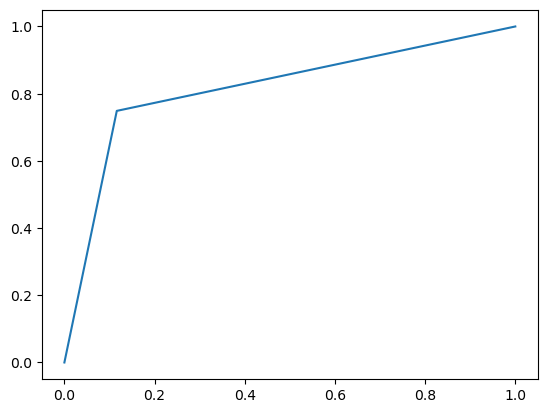

In [127]:
from sklearn.metrics import roc_curve, auc
fpr,tpr,thresholds = roc_curve(y_pred,y_test)
print('AUC:',auc(fpr,tpr))
plt.plot(fpr,tpr);

In [72]:
X_test[top_cols].iloc[10:20]
y_test.iloc[10:20]

,FamilyHistoryAlzheimers,SleepQuality,CardiovascularDisease,BehavioralProblems,DiastolicBP,Gender,CholesterolTriglycerides,MemoryComplaints,ADL,Ethnicity,Forgetfulness,BMI,Age,CholesterolHDL,PhysicalActivity,Disorientation,EducationLevel,FunctionalAssessment,AlcoholConsumption
10,0,8.856148,0,1,95,0,75.688736,0,8.136064,1,0,19.787231,65,71.526277,4.230477,0,1,3.179834,4.620082
11,0,4.903181,0,0,69,0,257.440543,0,1.513681,2,0,22.546746,61,28.026981,5.675808,0,0,2.313216,6.342811
12,1,8.572455,0,1,101,1,299.240235,1,9.238292,0,1,32.651525,74,81.531806,9.519232,0,1,9.153263,8.691890
13,0,7.988010,0,0,90,1,391.534840,0,1.855584,1,0,27.904365,64,55.613168,4.855612,0,1,6.837884,2.953001
14,1,8.373843,0,0,88,0,150.164616,0,0.754379,0,0,22.546918,71,78.009647,6.290657,0,1,7.316059,18.162116
15,0,4.013579,1,0,78,1,50.992717,0,6.898207,2,0,17.630318,69,87.592175,0.997862,1,2,7.555930,2.720553
16,0,4.463056,0,1,70,0,153.315778,0,1.159865,0,1,34.981655,88,59.624254,0.588361,0,1,9.570213,14.036820
17,0,4.874701,1,0,106,1,315.508175,1,5.244149,2,0,21.004163,63,94.087838,7.618554,0,2,0.044988,11.705233
18,0,7.747013,1,0,100,1,375.258282,0,9.309860,2,0,27.927760,64,28.117633,4.059717,0,2,4.111931,12.936216
19,0,4.071024,0,0,79,0,52.246497,0,5.300099,0,0,34.339301,89,34.488690,8.435659,0,1,0.330772,3.115090


10    0
11    1
12    1
13    0
14    0
15    0
16    1
17    1
18    0
19    0
Name: Diagnosis, dtype: int64

### Using multiple models at a time with all the features

In [73]:
columns = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 
           'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']

In [74]:
#normalize the columns
min_max_scaler = MinMaxScaler()
df[columns] = min_max_scaler.fit_transform(df[columns])

#standardize the columns
standard_scaler = StandardScaler()
df[columns] = standard_scaler.fit_transform(df[columns])

In [75]:
df.drop(['PatientID', 'DoctorInCharge'], axis=1, inplace=True)
X = df.drop(columns = ['Diagnosis'])
y = df['Diagnosis']

#split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = True)

In [76]:
param_grids = {
    'Decision Tree': {'max_depth': [3, 5, 7, 12]},
    'K-Nearest Neighbors': {'n_neighbors': [3, 5, 7]},
    'Guassian' : {'var_smoothing': [1e-9, 1e-6, 1e-3, 1e-2, 1e-1, 1]}
}

#instantiate classification models with default parameters
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Guassian' : GaussianNB(),
    'Decision Tree': DecisionTreeClassifier()
}

for name, model in models.items():
    grid_search = GridSearchCV(model, param_grids[name], cv = 5, scoring = 'f1')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    report = classification_report(y_test, y_pred)
    print(f'{name} Classification Report:\n{report}\nBest Parameters: {grid_search.best_params_}\n')

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7]}, scoring='f1')

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.87      0.80       277
           1       0.66      0.46      0.54       153

    accuracy                           0.72       430
   macro avg       0.70      0.67      0.67       430
weighted avg       0.71      0.72      0.71       430

Best Parameters: {'n_neighbors': 5}



GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-06, 0.001, 0.01, 0.1, 1]},
             scoring='f1')

Guassian Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.87       277
           1       0.84      0.62      0.71       153

    accuracy                           0.82       430
   macro avg       0.83      0.78      0.79       430
weighted avg       0.83      0.82      0.82       430

Best Parameters: {'var_smoothing': 0.1}



GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [3, 5, 7, 12]}, scoring='f1')

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       277
           1       0.93      0.87      0.90       153

    accuracy                           0.93       430
   macro avg       0.93      0.92      0.92       430
weighted avg       0.93      0.93      0.93       430

Best Parameters: {'max_depth': 5}

